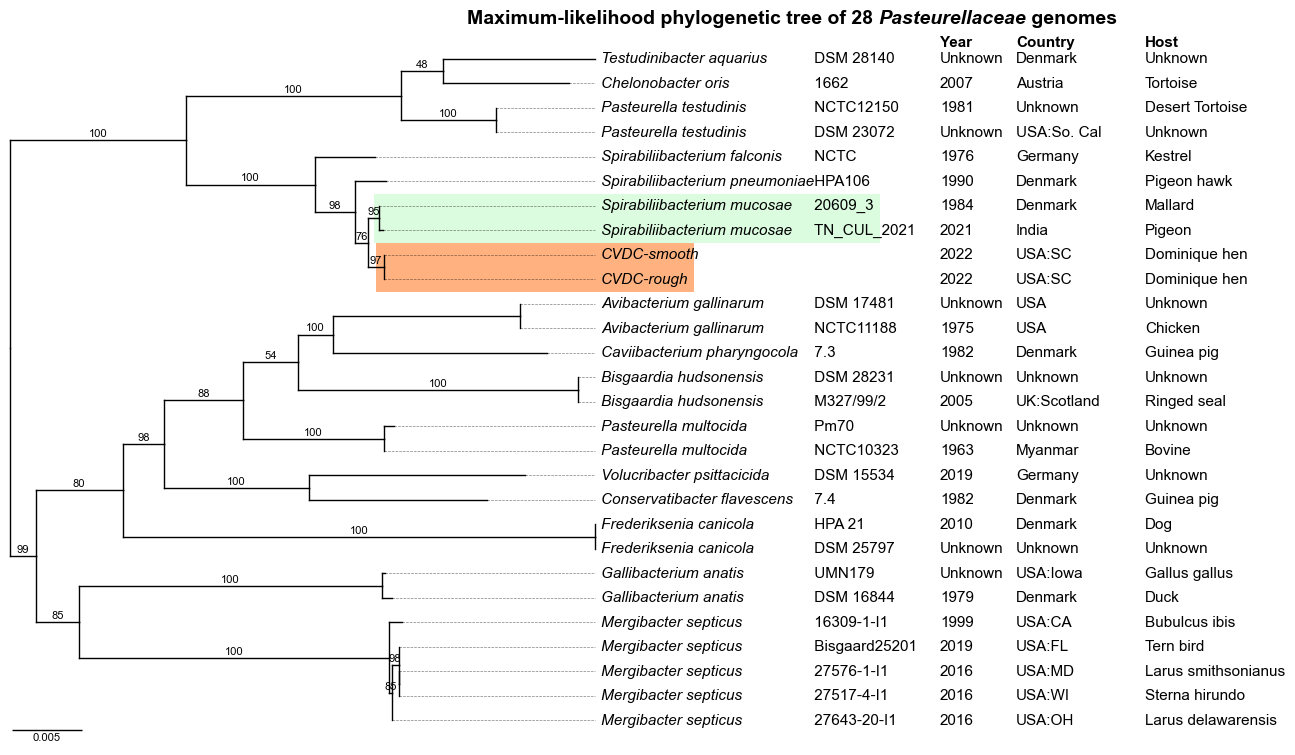

In [1]:
### 7/28/2026
import matplotlib.pyplot as plt
from Bio import Phylo
from phytreeviz import TreeViz
from matplotlib.patches import Patch

# 1. DATA SETUP
name_mapping = {
    "GCF_000772535.1": ["Chelonobacter oris 1662", "2007", "Austria", "Tortoise"],
    "GCF_000209675.1": ["Gallibacterium anatis UMN179", "Unknown", "USA:Iowa", "Gallus gallus"],
    "GCF_000379785.1": ["Gallibacterium anatis DSM 16844", "1979", "Denmark", "Duck"],
    "GCF_900176075.1": ["Pasteurella testudinis DSM 23072", "Unknown", "USA:So. Cal", "Unknown"],
    "GCF_900454705.1": ["Pasteurella testudinis NCTC12150", "1981", "Unknown", "Desert Tortoise"],
    "GCF_004342725.1": ["Testudinibacter aquarius DSM 28140", "Unknown", "Denmark", "Unknown"],
    "GCF_000006825.1": ["Pasteurella multocida Pm70", "Unknown", "Unknown", "Unknown"],
    "GCF_900638665.1": ["Pasteurella multocida NCTC10323", "1963", "Myanmar", "Bovine"],
    "GCF_004362535.1": ["Avibacterium gallinarum DSM 17481", "Unknown", "USA", "Unknown"],
    "GCF_900454485.1": ["Avibacterium gallinarum NCTC11188", "1975", "USA", "Chicken"],
    "GCF_013377195.1": ["Bisgaardia hudsonensis M327/99/2", "2005", "UK:Scotland", "Ringed seal"],
    "GCF_004345785.1": ["Bisgaardia hudsonensis DSM 28231", "Unknown", "Unknown", "Unknown"],
    "GCF_003265205.1": ["Mergibacter septicus 16309-1-I1", "1999", "USA:CA", "Bubulcus ibis"],
    "GCF_006770465.1": ["Mergibacter septicus 27576-1-I1", "2016", "USA:MD", "Larus smithsonianus"],
    "GCF_006770445.1": ["Mergibacter septicus 27643-20-I1", "2016", "USA:OH", "Larus delawarensis"],
    "GCF_024371585.1": ["Mergibacter septicus Bisgaard25201", "2019", "USA:FL", "Tern bird"],
    "GCF_003265225.1": ["Mergibacter septicus 27517-4-I1", "2016", "USA:WI", "Sterna hirundo"],
    "GCF_004339025.1": ["Volucribacter psittacicida DSM 15534", "2019", "Germany", "Unknown"],
    "GCF_003814575.1": ["Frederiksenia canicola DSM 25797", "Unknown", "Unknown", "Unknown"],
    "GCF_011455495.1": ["Frederiksenia canicola HPA 21", "2010", "Denmark", "Dog"],
    "GCF_002795405.1": ["Caviibacterium pharyngocola 7.3", "1982", "Denmark", "Guinea pig"],
    "GCF_002795425.1": ["Conservatibacter flavescens 7.4", "1982", "Denmark", "Guinea pig"],
    "rough1_genome_nextpolish": ["CVDC-rough", "2022", "USA:SC", "Dominique hen"],
    "smooth1_genome_nextpolish": ["CVDC-smooth", "2022", "USA:SC", "Dominique hen"],
    "ref1": ["Spirabiliibacterium mucosae 20609_3", "1984", "Denmark", "Mallard"],
    "ref2": ["Spirabiliibacterium pneumoniae HPA106", "1990", "Denmark", "Pigeon hawk"],
    "ref3": ["Spirabiliibacterium falconis NCTC", "1976", "Germany", "Kestrel"],
    "ref4": ["Spirabiliibacterium mucosae TN_CUL_2021", "2021", "India", "Pigeon"]
}


plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 11,
    'mathtext.fontset': 'custom',
    'mathtext.it': 'Arial:italic',
    'mathtext.rm': 'Arial'
})


# Split genus/species and strain
def split_species(name):
    words = name.split()
    genus_species = " ".join(words[:2])
    strain = " ".join(words[2:])
    return genus_species, strain


# 2. TREE SETUP
tree = Phylo.read(
    "polymorphisms_move.phy.treefile",
    "newick"
)

tree.root_at_midpoint()


metadata_lookup = {}

for leaf in tree.get_terminals():

    if leaf.name in name_mapping:

        data = name_mapping[leaf.name]

        full_name = data[0]

        metadata_lookup[full_name] = data[1:]

        # keep normal label temporarily
        leaf.name = full_name



temp_tree = "formatted_tree.nwk"

Phylo.write(
    tree,
    temp_tree,
    "newick"
)


# 3. PLOT TREE

tv = TreeViz(
    temp_tree,
    align_leaf_label=True,
    leaf_label_size=11
)


tv.show_confidence(
    ypos="top",
    label_formatter=lambda v: f"{int(v)}"
)


cvdc_labels = [
    name_mapping[k][0]
    for k in [
        "rough1_genome_nextpolish",
        "smooth1_genome_nextpolish"
    ]
]


ref_labels = [
    name_mapping[k][0]
    for k in [
        "ref1",
        "ref4"
    ]
]


tv.highlight(
    cvdc_labels,
    "#FF6600",
    alpha=0.5
)


tv.highlight(
    ref_labels,
    "#B9FBC0",
    alpha=0.5
)


tv.show_scale_bar()


fig = tv.plotfig()

ax = fig.gca()



# --------------------------------------------------
# APPLY SPECIES ITALICS
# --------------------------------------------------

fig.canvas.draw()

renderer = fig.canvas.get_renderer()


for text in list(ax.texts):

    label = text.get_text()


    if label in metadata_lookup:

        x, y = text.get_position()

        genus_species, strain = split_species(label)


        # remove original label
        text.set_visible(False)


        # italic species
        ax.text(
            x,
            y,
            genus_species,
            fontsize=11,
            fontfamily="Arial",
            fontstyle="italic",
            ha="left",
            va="center"
        )


        # normal strain
        if strain:

            ax.text(
                x + 0.015,
                y,
                " " + strain,
                fontsize=11,
                fontfamily="Arial",
                fontstyle="normal",
                ha="left",
                va="center"
            )



# --------------------------------------------------
# METADATA COLUMNS
# --------------------------------------------------

fig.canvas.draw()


max_x = 0


for t in ax.texts:

    bbox = t.get_window_extent(renderer)

    extent = ax.transData.inverted().transform(bbox)

    max_x = max(
        max_x,
        extent[1][0]
    )


x_range = ax.get_xlim()[1] - ax.get_xlim()[0]


col_year = max_x + x_range * 0.05
col_country = max_x + x_range * 0.18
col_host = max_x + x_range * 0.40



top_y = len(tree.get_terminals()) + 0.5


ax.text(
    col_year,
    top_y,
    "Year",
    fontweight="bold"
)


ax.text(
    col_country,
    top_y,
    "Country",
    fontweight="bold"
)


ax.text(
    col_host,
    top_y,
    "Host",
    fontweight="bold"
)



for label, values in metadata_lookup.items():

    year, country, host = values


    # find label position
    for t in ax.texts:

        if label.startswith(t.get_text()):

            y = t.get_position()[1]

            break

    else:
        continue


    ax.text(
        col_year,
        y,
        year,
        va="center"
    )


    ax.text(
        col_country,
        y,
        country,
        va="center"
    )


    ax.text(
        col_host,
        y,
        host,
        va="center"
    )



# --------------------------------------------------
# SAVE FIGURE
# --------------------------------------------------

plt.tight_layout()

fig.set_size_inches(
    13,
    8
)


plt.subplots_adjust(
    right=0.5,
    top=0.9,
    left=0.05
)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

min_x = float("inf")
max_x_all = float("-inf")

for t in ax.texts:
    bbox = t.get_window_extent(renderer)
    extent = ax.transData.inverted().transform(bbox)
    min_x = min(min_x, extent[0][0])
    max_x_all = max(max_x_all, extent[1][0])

center_x = (min_x + max_x_all) / 2

part1 = "Maximum-likelihood phylogenetic tree of 28 "
part2 = "Pasteurellaceae"
part3 = " genomes"

# temporarily draw part1 to measure its width
t1 = ax.text(
    center_x, top_y + 1.5, part1,
    fontsize=14, fontweight="bold",
    ha="center", va="top"
)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

bbox1 = t1.get_window_extent(renderer)
extent1 = ax.transData.inverted().transform(bbox1)
width1 = extent1[1][0] - extent1[0][0]

# now re-center: total width = part1 + part2 + part3
t2 = ax.text(
    center_x, top_y + 1.5, part2,
    fontsize=14, fontweight="bold", fontstyle="italic",
    ha="left", va="top"
)

t3 = ax.text(
    center_x, top_y + 1.5, part3,
    fontsize=14, fontweight="bold",
    ha="left", va="top"
)

fig.canvas.draw()

# measure full combined width and shift all three so they're centered together
bbox2 = t2.get_window_extent(renderer)
bbox3 = t3.get_window_extent(renderer)
extent2 = ax.transData.inverted().transform(bbox2)
extent3 = ax.transData.inverted().transform(bbox3)

total_width = extent3[1][0] - extent1[0][0]
start_x = center_x - total_width / 2

t1.set_position((start_x, top_y + 1.5))
t1.set_ha("left")

fig.canvas.draw()
bbox1 = t1.get_window_extent(renderer)
extent1 = ax.transData.inverted().transform(bbox1)
t2.set_position((extent1[1][0], top_y + 1.5))

fig.canvas.draw()
bbox2 = t2.get_window_extent(renderer)
extent2 = ax.transData.inverted().transform(bbox2)
t3.set_position((extent2[1][0], top_y + 1.5))


# fig.savefig(
#     "MDPI_Phylo_8_26_26.jpg",
#     dpi=600,
#     bbox_inches="tight"
# )


fig.savefig(
    "MDPI_PhylogeneticsTree_9_01_2026.tif",
    dpi=600,
    bbox_inches="tight",
    format="tiff",
    pil_kwargs={
        "compression": "tiff_lzw"
    }
)


plt.show()